In [2]:
import os
import math
import random
import re
import string
import hashlib
from collections import deque
from dataclasses import dataclass
from typing import Callable, Dict, List, Optional, Tuple
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.nn import functional as F
from model import GPTModel
from tokenizer import CharTokenizer
from dataclass import Instance, Task
from registry import TASKS
from save_data import save_mixed_trace_file

In [17]:
DATASET_SIZE = 50000
CORRECT_RATIO = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.52, 0.55, 0.58, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 1.0]

task_name = "word_index"
instances = [TASKS[task_name].sample() for _ in range(DATASET_SIZE)]

for rho in CORRECT_RATIO:
    save_mixed_trace_file(
        instances,
        correct_ratio=rho,
        output_file=f"{task_name}/{task_name}_rho_{int(rho*100)}.txt",
        seed=100,
    )

Saved: word_index/word_index_rho_0.txt
Total: 50000
Correct: 0 (0.00%)
Wrong: 50000 (100.00%)
Saved: word_index/word_index_rho_5.txt
Total: 50000
Correct: 2500 (5.00%)
Wrong: 47500 (95.00%)
Saved: word_index/word_index_rho_10.txt
Total: 50000
Correct: 5000 (10.00%)
Wrong: 45000 (90.00%)
Saved: word_index/word_index_rho_15.txt
Total: 50000
Correct: 7500 (15.00%)
Wrong: 42500 (85.00%)
Saved: word_index/word_index_rho_20.txt
Total: 50000
Correct: 10000 (20.00%)
Wrong: 40000 (80.00%)
Saved: word_index/word_index_rho_25.txt
Total: 50000
Correct: 12500 (25.00%)
Wrong: 37500 (75.00%)
Saved: word_index/word_index_rho_30.txt
Total: 50000
Correct: 15000 (30.00%)
Wrong: 35000 (70.00%)
Saved: word_index/word_index_rho_35.txt
Total: 50000
Correct: 17500 (35.00%)
Wrong: 32500 (65.00%)
Saved: word_index/word_index_rho_40.txt
Total: 50000
Correct: 20000 (40.00%)
Wrong: 30000 (60.00%)
Saved: word_index/word_index_rho_45.txt
Total: 50000
Correct: 22500 (45.00%)
Wrong: 27500 (55.00%)
Saved: word_index/wo

In [1]:

from tqdm.auto import tqdm
task_name = "word_index"
rho = 1.0
data_file = f"{task_name}/{task_name}_rho_{int(rho*100)}.txt"

batch_size = 256
steps = 6000
learning_rate = 3e-4
min_learning_rate = 1e-5
warmup_steps = 600
weight_decay = 0.01
max_grad_norm = 1.0

n_embd = 128
n_head = 4
n_layer = 4
dropout = 0.05

model_seed = 2200
val_seed = 99999
val_size = 1000
val_batch_size = 256

USE_COMPILE = True

device = "cuda" if torch.cuda.is_available() else "cpu"

if device == "cuda":
    torch.set_float32_matmul_precision("high")

use_bf16 = device == "cuda" and torch.cuda.is_bf16_supported()

task = TASKS[task_name]
tokenizer = task.tokenizer

block_size = task.block_size
max_new_tokens = task.max_new_tokens
pad_id = tokenizer.pad_id
newline_id = tokenizer.newline_id
vocab_size = tokenizer.vocab_size

print("Device:", device)
print("BF16:", use_bf16)


with open(data_file, "r", encoding="utf-8") as f:
    lines = [line.strip() for line in f if line.strip()]

print("Training file:", data_file)
print("Training examples:", len(lines))


train_prompts = {line.split(" ", 1)[0] for line in lines}
train_words = {prompt.split(";")[0] for prompt in train_prompts}


random.seed(val_seed)

val_instances = []
val_words = set()

while len(val_instances) < val_size:
    inst = task.sample()
    word = inst.prompt.split(";")[0]

    if word in train_words or word in val_words:
        continue

    val_words.add(word)
    val_instances.append(inst)

print("Validation examples:", len(val_instances))
print("Train/validation word overlap:", len(train_words & val_words))

assert train_words.isdisjoint(val_words)


encoded = []
max_seq_len = 0

for line in tqdm(lines, desc="Encoding"):
    prompt, continuation = line.split(" ", 1)

    p_ids = tokenizer.encode(prompt)
    t_ids = tokenizer.encode(" " + continuation + "\n")

    full = p_ids + t_ids

    if len(full) > block_size:
        raise ValueError(f"Sequence length {len(full)} exceeds block size {block_size}")

    x = full[:-1]
    y = full[1:]
    mask = [1.0 if i + 1 >= len(p_ids) else 0.0 for i in range(len(x))]

    encoded.append((x, y, mask))
    max_seq_len = max(max_seq_len, len(x))


print("Block size:", block_size)
print("Actual sequence length:", max_seq_len)


xs, ys, masks = [], [], []

for x, y, mask in tqdm(encoded, desc="Tensorizing"):
    pad = max_seq_len - len(x)

    xs.append(x + [pad_id] * pad)
    ys.append(y + [pad_id] * pad)
    masks.append(mask + [0.0] * pad)


xs = torch.tensor(xs, dtype=torch.long, device=device)
ys = torch.tensor(ys, dtype=torch.long, device=device)
masks = torch.tensor(masks, dtype=torch.float32, device=device)

del encoded, lines

print("Train tensor:", xs.shape)


random.seed(model_seed)
torch.manual_seed(model_seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(model_seed)


base_model = GPTModel(
    vocab_size=vocab_size,
    block_size=block_size,
    pad_id=pad_id,
    n_embd=n_embd,
    n_head=n_head,
    n_layer=n_layer,
    dropout=dropout
).to(device)

print("Parameters:", sum(p.numel() for p in base_model.parameters() if p.requires_grad))


model = torch.compile(base_model) if USE_COMPILE and device == "cuda" else base_model


try:
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
        fused=(device == "cuda")
    )
except:
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )


model.train()

pbar = tqdm(range(steps), desc=f"Training rho={rho}")

for step in pbar:

    if step < warmup_steps:
        lr = learning_rate * (step + 1) / warmup_steps
    else:
        decay = (step - warmup_steps) / (steps - warmup_steps)
        coeff = 0.5 * (1.0 + math.cos(math.pi * decay))
        lr = min_learning_rate + coeff * (learning_rate - min_learning_rate)

    for group in optimizer.param_groups:
        group["lr"] = lr

    ix = torch.randint(0, xs.shape[0], (batch_size,), device=device)

    xb = xs[ix]
    yb = ys[ix]
    mb = masks[ix]

    optimizer.zero_grad(set_to_none=True)

    if use_bf16:
        with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            _, loss = model(xb, targets=yb, mask=mb)
    else:
        _, loss = model(xb, targets=yb, mask=mb)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
    optimizer.step()

    if step % 50 == 0:
        pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{lr:.2e}")


print("\nTraining finished.")
print("Running validation once...")


base_model.eval()

correct = 0
separator_count = 0

val_prompt_tensor = torch.tensor(
    [tokenizer.encode(inst.prompt) for inst in val_instances],
    dtype=torch.long,
    device=device
)


with torch.inference_mode():

    for start in tqdm(range(0, val_size, val_batch_size), desc="Validation"):

        end = min(start + val_batch_size, val_size)
        context = val_prompt_tensor[start:end]

        out = base_model.generate(
            context,
            max_new_tokens=max_new_tokens,
            stop_id=newline_id,
            greedy=True
        )

        for row, inst in zip(out.tolist(), val_instances[start:end]):

            text = tokenizer.decode(row)
            generated = text[len(inst.prompt):].split("\n", 1)[0]

            if ":" in generated:
                separator_count += 1
                answer = generated.rsplit(":", 1)[1]
                nums = re.findall(r"\d+", answer)
                pred = nums[0] if nums else None
            else:
                pred = None

            correct += int(pred == inst.gold)


val_acc = correct / val_size
separator_rate = separator_count / val_size

print()
print(f"ρ = {rho:.1f}")
print(f"Validation accuracy = {val_acc*100:.2f}%")
print(f"Separator rate = {separator_rate*100:.2f}%")




NameError: name 'torch' is not defined

In [11]:
import torch

task_name = "word_index"

task = TASKS[task_name]
tokenizer = task.tokenizer

newline_id = tokenizer.encode("\n")[0]

test_prompt = "aditya;y"

context = torch.tensor(
    [tokenizer.encode(test_prompt)],
    dtype=torch.long,
    device=device
)

base_model.eval()

with torch.no_grad():
    generated = base_model.generate(
        context,
        max_new_tokens=40,
        stop_id=newline_id,
        greedy=True
    )[0].tolist()

text = tokenizer.decode(generated)

print("Model output:")
print(text)

word, char = test_prompt.split(";")
gold = word.index(char)

print("Gold answer:", gold)

Model output:
aditya;y  1  0a 1d 2i 3t 4y 5a 6d 7y 8  9  : 4

Gold answer: 4


In [3]:
import math, random, re, gc, torch
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from model import GPTModel
from registry import TASKS


task_name = "word_index"
rho_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.45, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

batch_size = 128
steps = 6000
learning_rate = 3e-4
min_learning_rate = 1e-5
warmup_steps = 600
weight_decay = 0.01
max_grad_norm = 1.0

n_embd = 128
n_head = 4
n_layer = 4
dropout = 0.05

model_seed = 2200
val_seed = 99999
val_size = 1000
val_batch_size = 256

USE_COMPILE = True

device = "cuda" if torch.cuda.is_available() else "cpu"

if device == "cuda":
    torch.set_float32_matmul_precision("high")

use_bf16 = device == "cuda" and torch.cuda.is_bf16_supported()

task = TASKS[task_name]
tokenizer = task.tokenizer

block_size = task.block_size
max_new_tokens = task.max_new_tokens
pad_id = tokenizer.pad_id
newline_id = tokenizer.newline_id
vocab_size = tokenizer.vocab_size

print("Device:", device)
print("BF16:", use_bf16)


first_file = f"{task_name}/{task_name}_rho_0.txt"

with open(first_file, "r", encoding="utf-8") as f:
    first_lines = [line.strip() for line in f if line.strip()]

train_prompts = {line.split(" ", 1)[0] for line in first_lines}
train_words = {prompt.split(";")[0] for prompt in train_prompts}


random.seed(val_seed)

val_instances = []
val_words = set()

while len(val_instances) < val_size:
    inst = task.sample()
    word = inst.prompt.split(";")[0]

    if word in train_words or word in val_words:
        continue

    val_words.add(word)
    val_instances.append(inst)

print("Validation examples:", len(val_instances))
print("Train/validation overlap:", len(train_words & val_words))

val_prompt_tensor = torch.tensor(
    [tokenizer.encode(inst.prompt) for inst in val_instances],
    dtype=torch.long,
    device=device
)


accuracies = []
separator_rates = []


for rho in rho_values:

    print("\n" + "=" * 70)
    print(f"RHO = {rho}")
    print("=" * 70)

    data_file = f"{task_name}/{task_name}_rho_{int(rho*100)}.txt"

    with open(data_file, "r", encoding="utf-8") as f:
        lines = [line.strip() for line in f if line.strip()]

    print("Training file:", data_file)
    print("Examples:", len(lines))


    encoded = []
    max_seq_len = 0

    for line in tqdm(lines, desc=f"Encoding rho={rho}", leave=False):
        prompt, continuation = line.split(" ", 1)

        p_ids = tokenizer.encode(prompt)
        t_ids = tokenizer.encode(" " + continuation + "\n")

        full = p_ids + t_ids

        if len(full) > block_size:
            raise ValueError(f"Sequence length {len(full)} > block size {block_size}")

        x = full[:-1]
        y = full[1:]
        mask = [1.0 if i + 1 >= len(p_ids) else 0.0 for i in range(len(x))]

        encoded.append((x, y, mask))
        max_seq_len = max(max_seq_len, len(x))


    xs, ys, masks = [], [], []

    for x, y, mask in encoded:
        pad = max_seq_len - len(x)

        xs.append(x + [pad_id] * pad)
        ys.append(y + [pad_id] * pad)
        masks.append(mask + [0.0] * pad)

    xs = torch.tensor(xs, dtype=torch.long, device=device)
    ys = torch.tensor(ys, dtype=torch.long, device=device)
    masks = torch.tensor(masks, dtype=torch.float32, device=device)

    del encoded, lines


    random.seed(model_seed)
    torch.manual_seed(model_seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(model_seed)


    base_model = GPTModel(
        vocab_size=vocab_size,
        block_size=block_size,
        pad_id=pad_id,
        n_embd=n_embd,
        n_head=n_head,
        n_layer=n_layer,
        dropout=dropout
    ).to(device)

    model = torch.compile(base_model) if USE_COMPILE and device == "cuda" else base_model


    try:
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay,
            fused=(device == "cuda")
        )
    except:
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )


    model.train()

    pbar = tqdm(range(steps), desc=f"Training ρ={rho:.1f}")

    for step in pbar:

        if step < warmup_steps:
            lr = learning_rate * (step + 1) / warmup_steps
        else:
            decay = (step - warmup_steps) / (steps - warmup_steps)
            coeff = 0.5 * (1.0 + math.cos(math.pi * decay))
            lr = min_learning_rate + coeff * (learning_rate - min_learning_rate)

        for group in optimizer.param_groups:
            group["lr"] = lr

        ix = torch.randint(0, xs.shape[0], (batch_size,), device=device)

        xb = xs[ix]
        yb = ys[ix]
        mb = masks[ix]

        optimizer.zero_grad(set_to_none=True)

        if use_bf16:
            with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                _, loss = model(xb, targets=yb, mask=mb)
        else:
            _, loss = model(xb, targets=yb, mask=mb)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

        if step % 50 == 0:
            pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{lr:.2e}")


    base_model.eval()

    correct = 0
    separator_count = 0

    with torch.inference_mode():

        for start in tqdm(
            range(0, val_size, val_batch_size),
            desc=f"Validation rho={rho}",
            leave=False
        ):

            end = min(start + val_batch_size, val_size)
            context = val_prompt_tensor[start:end]

            out = base_model.generate(
                context,
                max_new_tokens=max_new_tokens,
                stop_id=newline_id,
                greedy=True
            )

            for row, inst in zip(out.tolist(), val_instances[start:end]):

                text = tokenizer.decode(row)
                generated = text[len(inst.prompt):].split("\n", 1)[0]

                if ":" in generated:
                    separator_count += 1
                    answer = generated.rsplit(":", 1)[1]
                    nums = re.findall(r"\d+", answer)
                    pred = nums[0] if nums else None
                else:
                    pred = None

                correct += int(pred == inst.gold)


    val_acc = correct / val_size
    separator_rate = separator_count / val_size

    accuracies.append(val_acc)
    separator_rates.append(separator_rate)


    print(f"ρ={rho:.1f} | accuracy={val_acc*100:.2f}% | separator={separator_rate*100:.2f}%")


    torch.save(
        base_model.state_dict(),
        f"{task_name}/{task_name}_rho_{int(rho*100)}_model.pt"
    )


    del model, base_model, optimizer, xs, ys, masks

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


print("\nFINAL RESULTS")

for rho, acc, sep in zip(rho_values, accuracies, separator_rates):
    print(f"rho={rho:.1f} | accuracy={acc*100:.2f}% | separator={sep*100:.2f}%")


Device: cuda
BF16: True
Validation examples: 1000
Train/validation overlap: 0

RHO = 0.0
Training file: word_index/word_index_rho_0.txt
Examples: 50000


Encoding rho=0.0:   0%|          | 0/50000 [00:00<?, ?it/s]

Training ρ=0.0:   0%|          | 0/6000 [00:00<?, ?it/s]

Validation rho=0.0:   0%|          | 0/4 [00:00<?, ?it/s]

ρ=0.0 | accuracy=9.00% | separator=100.00%

RHO = 0.1
Training file: word_index/word_index_rho_10.txt
Examples: 50000


...

ρ=0.9 | accuracy=83.90% | separator=100.00%

RHO = 1.0
Training file: word_index/word_index_rho_100.txt
Examples: 50000


Encoding rho=1.0:   0%|          | 0/50000 [00:00<?, ?it/s]

Training ρ=1.0:   0%|          | 0/6000 [00:00<?, ?it/s]

Validation rho=1.0:   0%|          | 0/4 [00:00<?, ?it/s]

ρ=1.0 | accuracy=83.20% | separator=100.00%

FINAL RESULTS
rho=0.0 | accuracy=9.00% | separator=100.00%
rho=0.1 | accuracy=9.60% | separator=100.00%
rho=0.2 | accuracy=9.30% | separator=100.00%
rho=0.3 | accuracy=9.90% | separator=100.00%
rho=0.4 | accuracy=9.50% | separator=100.00%
rho=0.5 | accuracy=8.70% | separator=100.00%
rho=0.5 | accuracy=9.20% | separator=100.00%
rho=0.6 | accuracy=36.40% | separator=100.00%
rho=0.6 | accuracy=82.10% | separator=100.00%
rho=0.7 | accuracy=82.70% | separator=100.00%
rho=0.7 | accuracy=82.80% | separator=100.00%
rho=0.8 | accuracy=82.50% | separator=100.00%
rho=0.9 | accuracy=83.90% | separator=100.00%
rho=1.0 | accuracy=83.20% | separator=100.00%


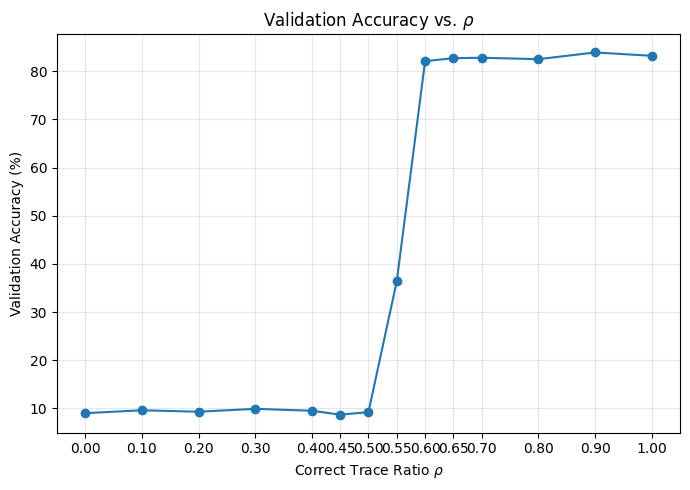

In [4]:
plt.figure(figsize=(7, 5))

plt.plot(
    rho_values,
    [100 * x for x in accuracies],
    marker="o"
)

plt.xlabel(r"Correct Trace Ratio $\rho$")
plt.ylabel("Validation Accuracy (%)")
plt.title(r"Validation Accuracy vs. $\rho$")
plt.xticks(rho_values)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()